# Object Detection for Self-Driving Cars

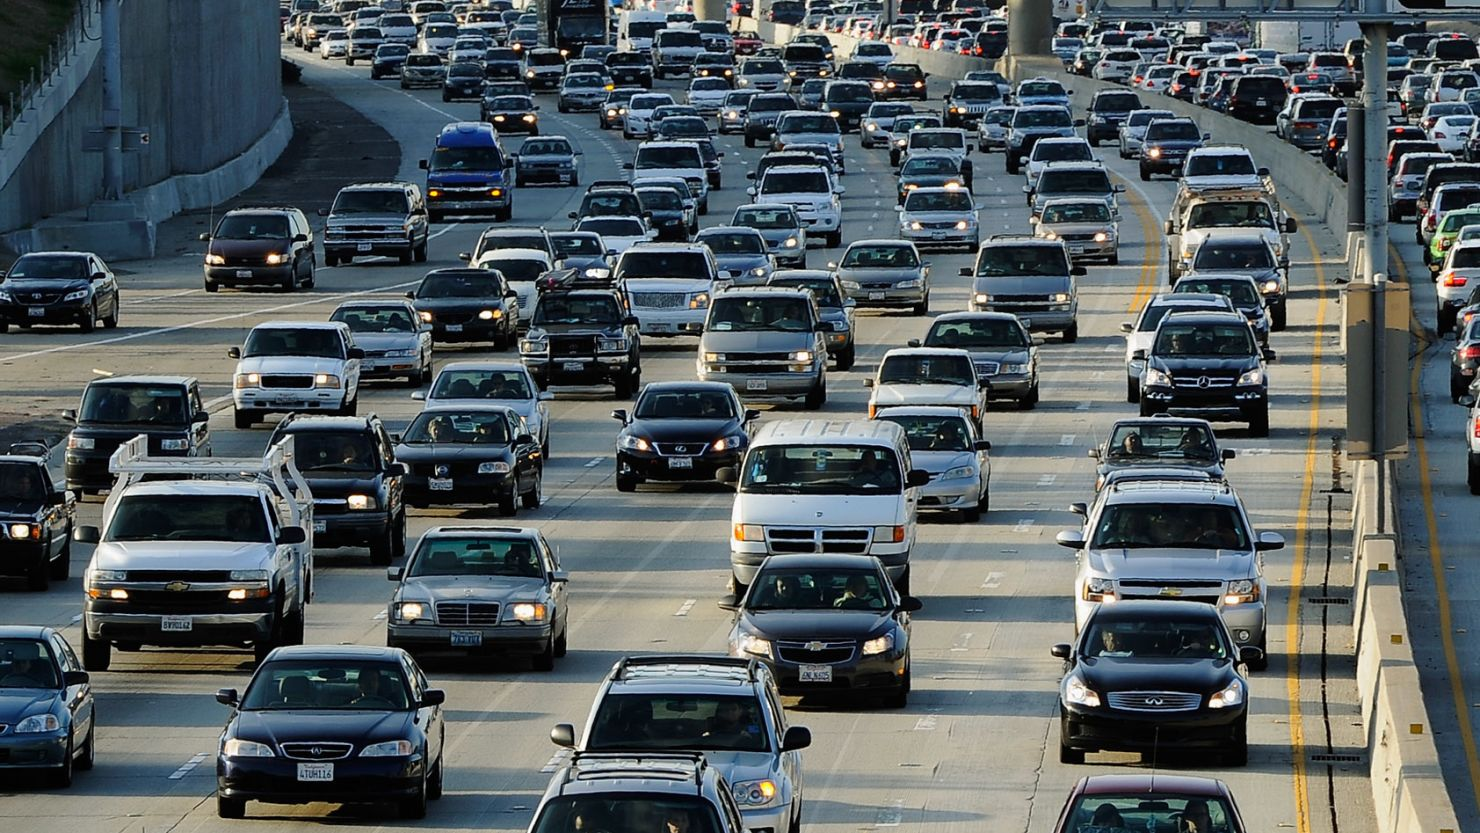

<a class="anchor" id="About_Data"></a>
# <p style="padding:10px;background-color:#d5eae9;margin:0;color:#c27849;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Model 1: YOLO</p> 

In [1]:
import os
# Must be set before importing cv2
os.environ["OPENCV_LOG_LEVEL"] = "SILENT"

In [2]:
import cv2
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Install required packages
!pip install -q ultralytics pycocotools torchmetrics albumentations tqdm

# Python imports
import os
import json
import shutil
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split

import torch
print("Torch:", torch.__version__, "CUDA available:", torch.cuda.is_available(), "CUDA:", torch.version.cuda)


Torch: 2.1.2 CUDA available: True CUDA: 12.1


In [4]:
# Paths & seed - adjust if your dataset path differs
ROOT = Path("/kaggle/input/car-camera-photos")
IMAGES_DIR = ROOT / "images"
CSV_PATH = ROOT / "labels_train.csv"

WORK_DIR = Path("/kaggle/working")
DATA_DIR = WORK_DIR / "datasets"
YOLO_DIR = DATA_DIR / "yolo"
COCO_DIR = DATA_DIR / "coco"

os.makedirs(YOLO_DIR, exist_ok=True)
os.makedirs(COCO_DIR, exist_ok=True)

# set reproducible seed
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("CSV exists:", CSV_PATH.exists())
print("Some example images exist:", (IMAGES_DIR).exists())


CSV exists: True
Some example images exist: True


In [5]:
# Load CSV
df = pd.read_csv(CSV_PATH)

print("CSV columns:", df.columns.tolist())

# Ensure filenames are strings with .jpg extension
df['frame'] = df['frame'].astype(str).str.strip()
df['frame'] = df['frame'].apply(lambda x: x if x.endswith(".jpg") else x + ".jpg")

# Train/val split (80/20)
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))


CSV columns: ['frame', 'xmin', 'xmax', 'ymin', 'ymax', 'class_id']
Train samples: 105924
Val samples: 26482


In [6]:
# Correct images directory
IMAGES_DIR = Path("/kaggle/input/car-camera-photos/images/images")

# CSV path stays the same
CSV_PATH = Path("/kaggle/input/car-camera-photos/labels_train.csv")

In [7]:
from tqdm import tqdm
from collections import defaultdict

splits = {'train': train_df, 'val': val_df}

for split, split_df in splits.items():
    img_out = YOLO_DIR / split / "images"
    lbl_out = YOLO_DIR / split / "labels"
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)

    # --- Step 1: cache image sizes ---
    size_cache = {}
    print(f"\n[{split.upper()}] Caching image sizes...")
    for img_name in tqdm(split_df['frame'].unique(), desc=f"{split} images"):
        img_file = IMAGES_DIR / img_name
        if not img_file.exists():
            continue
        img = cv2.imread(str(img_file))
        if img is None:
            continue
        h_img, w_img = img.shape[:2]
        size_cache[img_name] = (h_img, w_img)
        shutil.copy(img_file, img_out / img_file.name)

    # --- Step 2: write labels ---
    print(f"[{split.upper()}] Writing YOLO labels...")
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"{split} labels"):
        img_name = row['frame']
        if img_name not in size_cache:
            continue
        h_img, w_img = size_cache[img_name]

        cls = int(row['class_id']) - 1
        x_center = (row['xmin'] + row['xmax']) / 2 / w_img
        y_center = (row['ymin'] + row['ymax']) / 2 / h_img
        w = (row['xmax'] - row['xmin']) / w_img
        h = (row['ymax'] - row['ymin']) / h_img

        with open(lbl_out / f"{Path(img_name).stem}.txt", "a") as f:
            f.write(f"{cls} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

print("\n✅ Optimized YOLO dataset prepared successfully!")



[TRAIN] Caching image sizes...


train images: 100%|██████████| 17707/17707 [04:36<00:00, 64.11it/s]


[TRAIN] Writing YOLO labels...


train labels: 100%|██████████| 105924/105924 [00:16<00:00, 6512.75it/s]



[VAL] Caching image sizes...


val images: 100%|██████████| 12950/12950 [00:50<00:00, 257.82it/s]


[VAL] Writing YOLO labels...


val labels: 100%|██████████| 26482/26482 [00:04<00:00, 5916.59it/s]


✅ Optimized YOLO dataset prepared successfully!


In [21]:
# Count images and labels
train_imgs = list((YOLO_DIR / "train" / "images").glob("*.jpg"))
val_imgs   = list((YOLO_DIR / "val" / "images").glob("*.jpg"))
train_lbls = list((YOLO_DIR / "train" / "labels").glob("*.txt"))
val_lbls   = list((YOLO_DIR / "val" / "labels").glob("*.txt"))

print("YOLO train images:", len(train_imgs))
print("YOLO val images:", len(val_imgs))
print("YOLO train labels:", len(train_lbls))
print("YOLO val labels:", len(val_lbls))

YOLO train images: 17707
YOLO val images: 12950
YOLO train labels: 17707
YOLO val labels: 12950


In [22]:
import yaml

class_names = sorted(df['class_id'].unique().tolist())
names = [f"class_{c}" for c in class_names]

data_yaml = {
    'train': str(YOLO_DIR / "train" / "images"),
    'val':   str(YOLO_DIR / "val" / "images"),
    'nc':    len(class_names),
    'names': names
}

with open(DATA_DIR / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("✅ data.yaml saved at:", DATA_DIR / "data.yaml")


✅ data.yaml saved at: /kaggle/working/datasets/data.yaml


In [23]:
from ultralytics import YOLO

# Load pretrained YOLOv8 (you can pick n, s, m, l depending on GPU)
model = YOLO("yolov8n.pt")  

# Train
model.train(
    data=str(DATA_DIR / "data.yaml"),
    epochs=50,
    imgsz=640,
    batch=32,
    device=0  # use GPU P100
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.202 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/datasets/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7

2025-09-20 07:39:36,658	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-09-20 07:39:37,348	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7904ce28bdc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [26]:
# Run validation silently
metrics = model.val(verbose=False)
print(metrics)

Ultralytics 8.3.202 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1059.4±201.3 MB/s, size: 42.8 KB)
val: Scanning /kaggle/working/datasets/yolo/val/labels.cache... 12950 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 12950/12950 17.5Mit/s 0.0s
val: /kaggle/working/datasets/yolo/val/images/1478732688555973177.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 405/405 6.6it/s 1:02<0.1ss
                   all      12950      26481       0.23      0.625      0.197      0.108
Speed: 0.1ms preprocess, 1.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/train4
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x790

WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /kaggle/working/runs/detect/predict3


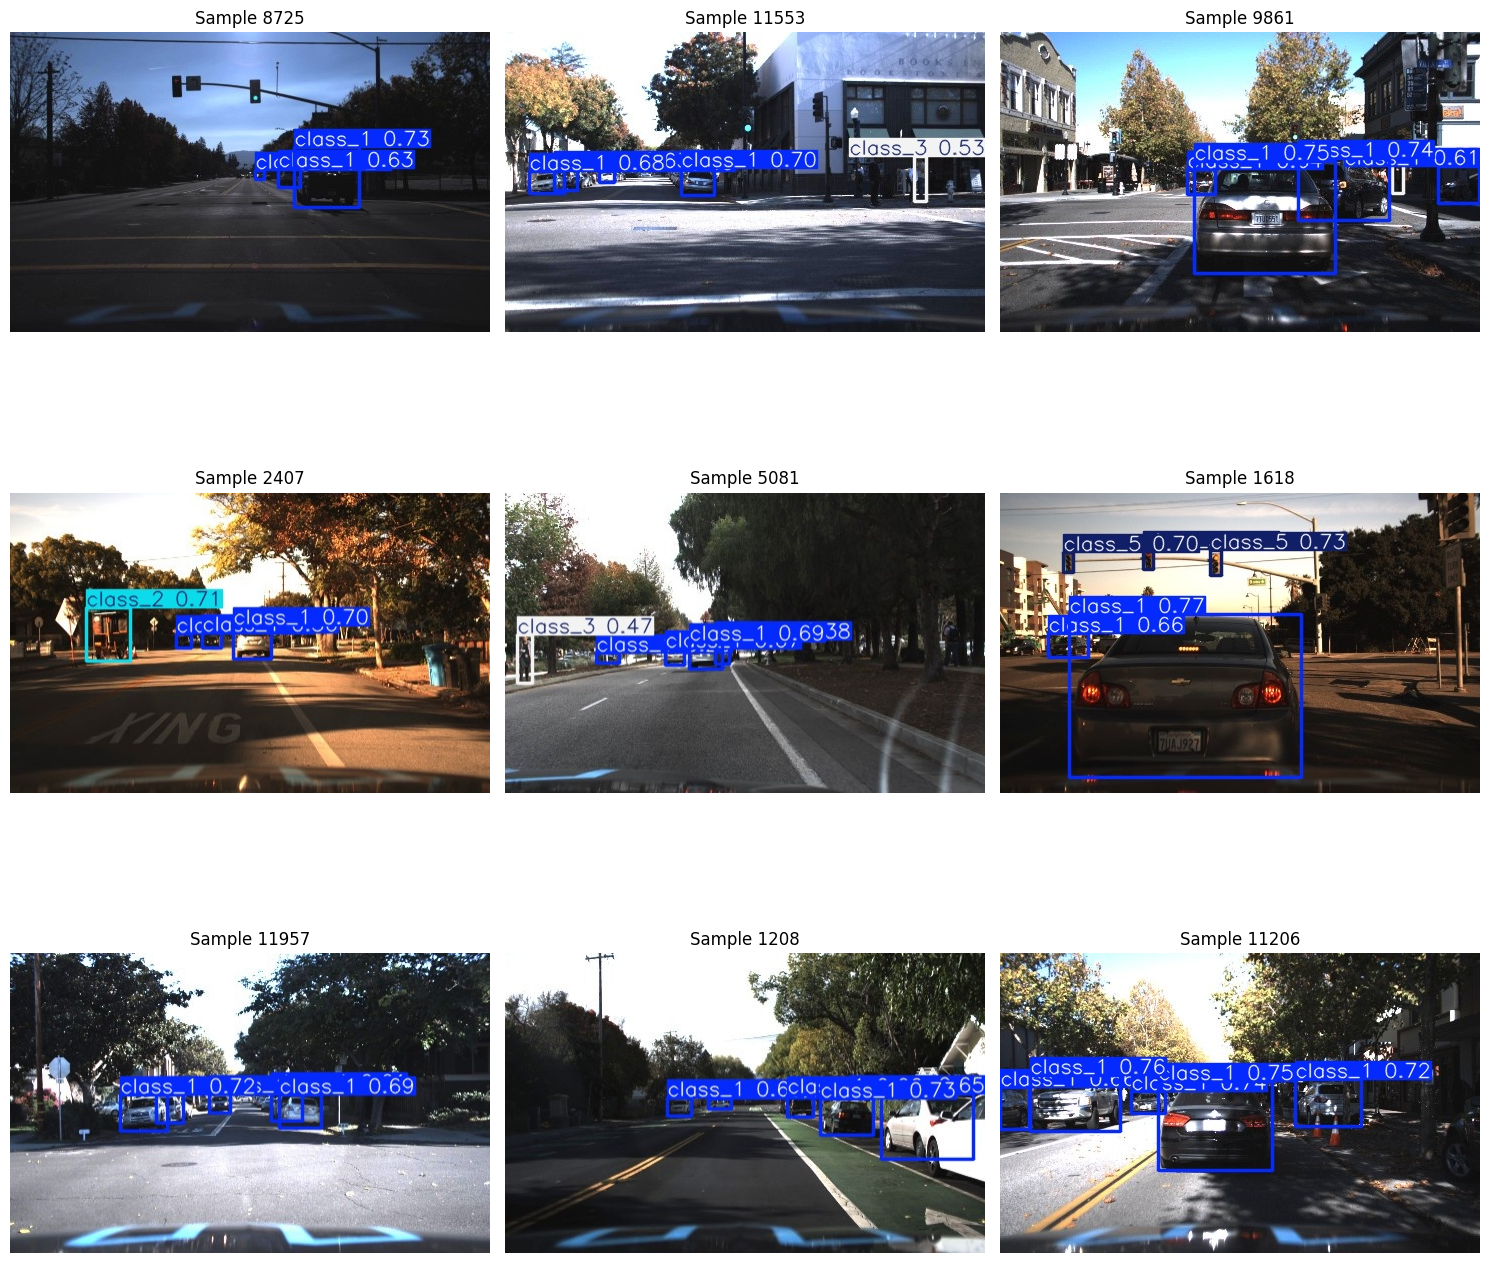

In [29]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import random

# Load trained model
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

# Run prediction on validation images
results = model.predict(
    source="/kaggle/working/datasets/yolo/val/images",
    save=True,
    conf=0.25,
    imgsz=640,
    verbose=False,
    max_det=5,
    save_txt=False
)

# Pick 9 random results
n_show = min(9, len(results))
sample_indices = random.sample(range(len(results)), n_show)

# Plot in grid
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i, ax in enumerate(axes.flat):
    if i < n_show:
        idx = sample_indices[i]
        pred_img_path = Path(results[idx].save_dir) / Path(results[idx].path).name
        img = cv2.imread(str(pred_img_path))
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            ax.axis("off")
            ax.set_title(f"Sample {idx}")
        else:
            ax.axis("off")
            ax.set_title("Image not found")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()


<a class="anchor" id="About_Data"></a>
# <p style="padding:10px;background-color:#d5eae9;margin:0;color:#c27849;font-family:newtimeroman;font-size:150%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">Model 2: SSD</p> 

In [32]:
class YOLO2SSD_Dataset(Dataset):
    def __init__(self, img_dir, label_dir, transforms=None):
        self.img_dir = Path(img_dir)
        self.label_dir = Path(label_dir)
        self.imgs = list(self.img_dir.glob("*.jpg"))
        self.transforms = transforms

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = self.imgs[idx]
        label_path = self.label_dir / (img_path.stem + ".txt")

        # Load image
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        orig_h, orig_w = img.shape[:2]

        boxes = []
        labels = []

        # Load YOLO labels and convert to absolute SSD coordinates
        if label_path.exists():
            with open(label_path) as f:
                for line in f.readlines():
                    cls, x, y, bw, bh = map(float, line.strip().split())
                    xmin = (x - bw/2) * orig_w
                    xmax = (x + bw/2) * orig_w
                    ymin = (y - bh/2) * orig_h
                    ymax = (y + bh/2) * orig_h

                    # Skip degenerate boxes
                    if xmax - xmin > 0 and ymax - ymin > 0:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(int(cls)+1)  # SSD labels start at 1

        # Resize image to 300x300
        if self.transforms:
            img = self.transforms(img)

        # Scale boxes to match resized image
        scale_x = 300 / orig_w
        scale_y = 300 / orig_h
        boxes = [[xmin*scale_x, ymin*scale_y, xmax*scale_x, ymax*scale_y] for xmin, ymin, xmax, ymax in boxes]

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        # Clamp boxes to [0, 300]
        if boxes.numel() > 0:
            boxes[:, 0] = boxes[:, 0].clamp(0, 299)  # xmin
            boxes[:, 1] = boxes[:, 1].clamp(0, 299)  # ymin
            boxes[:, 2] = boxes[:, 2].clamp(1, 300)  # xmax
            boxes[:, 3] = boxes[:, 3].clamp(1, 300)  # ymax

            # Remove degenerate boxes after clamping
            widths = boxes[:, 2] - boxes[:, 0]
            heights = boxes[:, 3] - boxes[:, 1]
            keep = (widths > 0) & (heights > 0)
            boxes = boxes[keep]
            labels = labels[keep]

        target = {"boxes": boxes, "labels": labels}
        return img, target


In [33]:
transform = T.Compose([
    T.ToTensor(),         # convert to float32 [0,1]
    T.Resize((300,300)),  # SSD input size
])

train_dataset = YOLO2SSD_Dataset(
    img_dir="/kaggle/working/datasets/yolo/train/images",
    label_dir="/kaggle/working/datasets/yolo/train/labels",
    transforms=transform
)
val_dataset = YOLO2SSD_Dataset(
    img_dir="/kaggle/working/datasets/yolo/val/images",
    label_dir="/kaggle/working/datasets/yolo/val/labels",
    transforms=transform
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))


In [34]:
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDClassificationHead

num_classes = 6  # 5 classes + background
model = ssd300_vgg16(pretrained=True)

in_channels = [c.in_channels for c in model.head.classification_head.module_list]
num_anchors = model.anchor_generator.num_anchors_per_location()

model.head.classification_head = SSDClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_classes
)

model.to(device)


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [35]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.0001, momentum=0.9, weight_decay=0.0005)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for imgs, targets in train_loader:
        # Skip images with empty targets
        non_empty = [i for i, t in enumerate(targets) if t["boxes"].numel() > 0]
        if len(non_empty) == 0:
            continue

        imgs = [imgs[i].to(device) for i in non_empty]
        targets = [{k: v.to(device) for k, v in targets[i].items()} for i in non_empty]

        loss_dict = model(imgs, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")


Epoch 1/10, Loss: 3.9949
Epoch 2/10, Loss: 3.1624
Epoch 3/10, Loss: 2.9845
Epoch 4/10, Loss: 2.8717
Epoch 5/10, Loss: 2.7803
Epoch 6/10, Loss: 2.7145
Epoch 7/10, Loss: 2.6514
Epoch 8/10, Loss: 2.5986
Epoch 9/10, Loss: 2.5499
Epoch 10/10, Loss: 2.5034


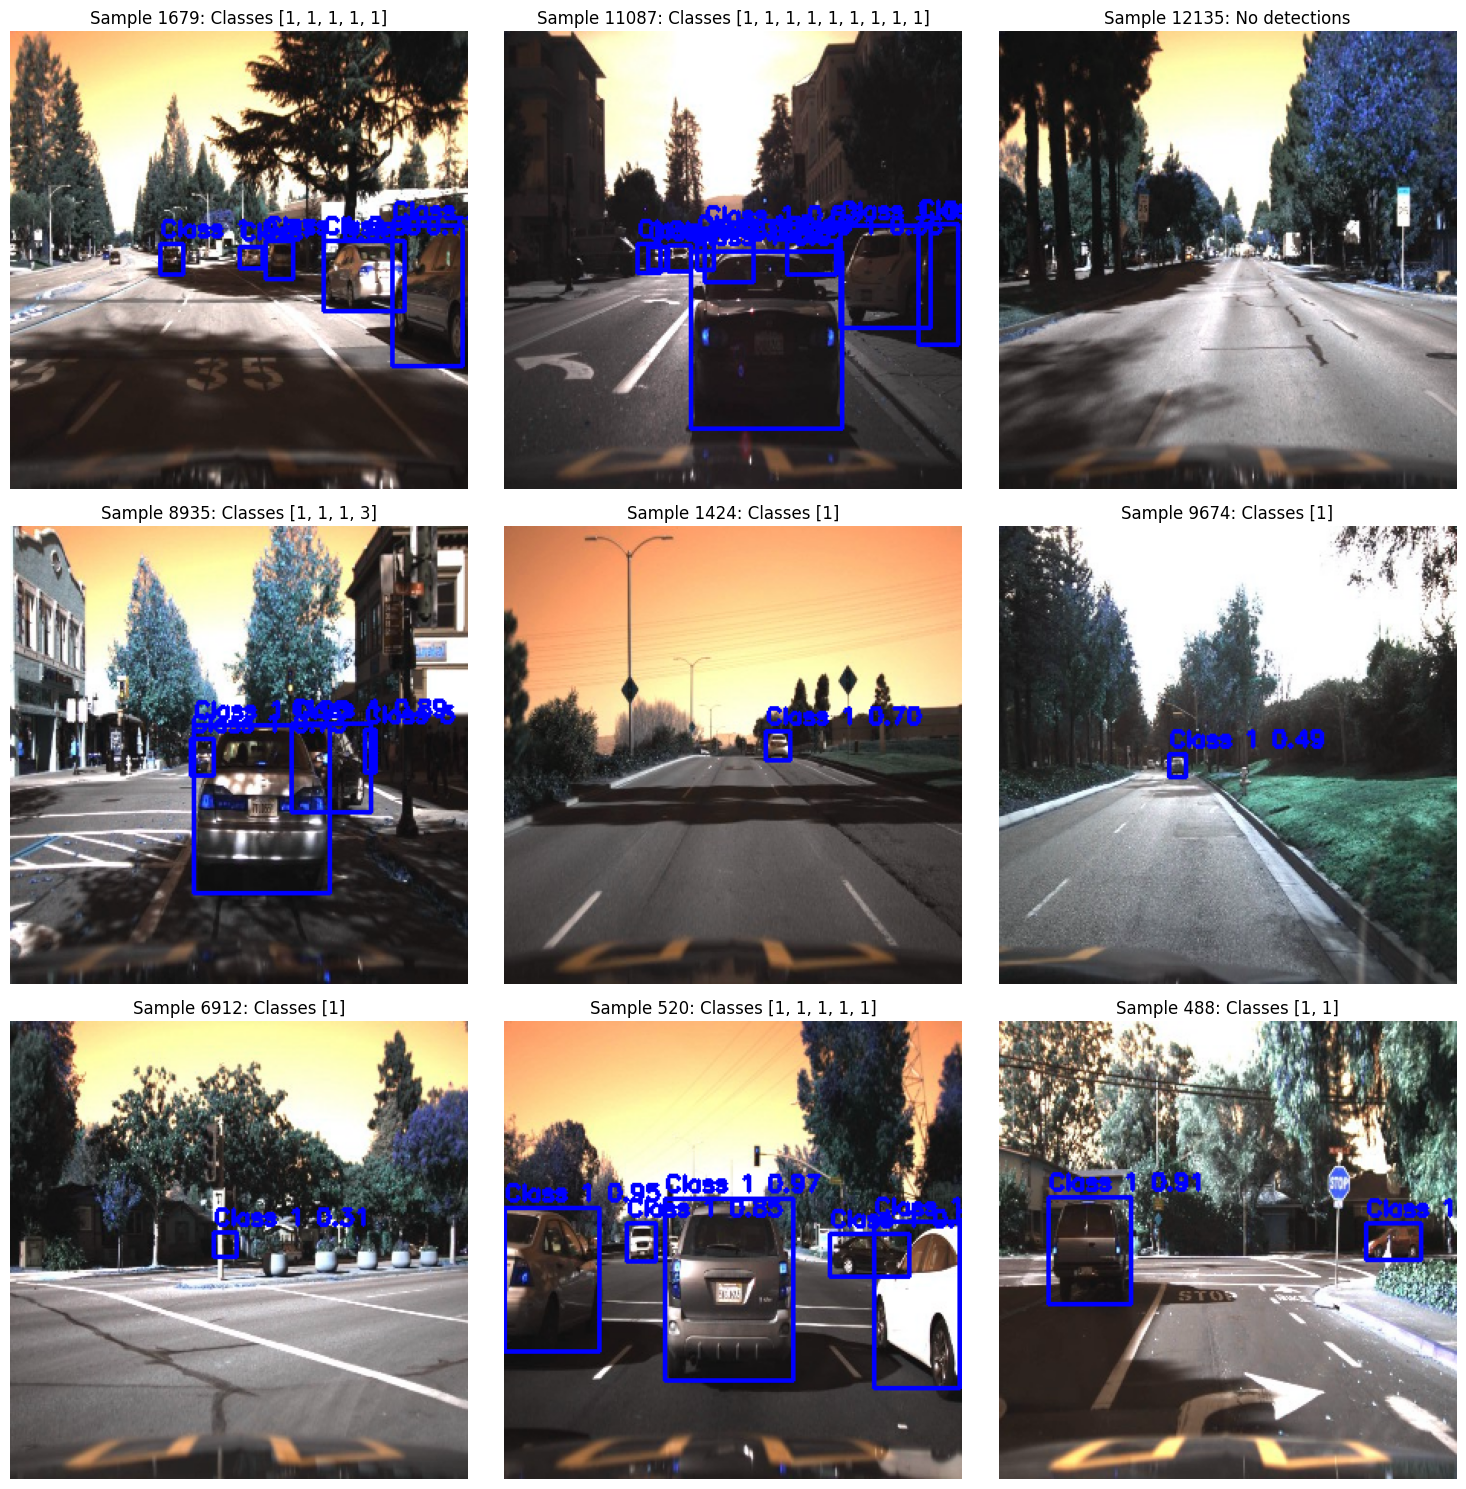

In [39]:
import matplotlib.pyplot as plt
import cv2
import random
import torch

model.eval()

# Number of samples to show
n_show = 9

# Pick random indices from validation dataset
sample_indices = random.sample(range(len(val_dataset)), n_show)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i, ax in enumerate(axes.flat):
    if i < n_show:
        idx = sample_indices[i]
        img_tensor, target = val_dataset[idx]
        img = img_tensor.to(device)

        # Run prediction
        with torch.no_grad():
            prediction = model([img])[0]

        # Convert image for plotting
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_np = (img_np * 255).astype(np.uint8)
        img_np = np.ascontiguousarray(img_np)

        # Collect predicted classes for title
        pred_classes = []
        for box, cls, score in zip(prediction["boxes"], prediction["labels"], prediction["scores"]):
            if score > 0.3:
                x1, y1, x2, y2 = map(int, box.tolist())
                cv2.rectangle(img_np, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.putText(img_np, f"Class {cls.item()} {score:.2f}", (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
                pred_classes.append(cls.item())

        # Convert to RGB for matplotlib
        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.axis("off")

        # Show predicted classes and count in title
        if pred_classes:
            class_str = ", ".join(str(c) for c in pred_classes)
            ax.set_title(f"Sample {idx}: Classes [{class_str}]")
        else:
            ax.set_title(f"Sample {idx}: No detections")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()


<div style="background-color:#d5eae9; padding:20px; font-size:15px">

**Tanks for the time you took to observe this notebook** 


**Author: Mohammad Bagher Soroush**